# BYOL Downstream Classification Evaluation — LoTSS initial_pure

Evaluates BYOL encoder representations on the LoTSS initial_pure 5-class task,
using the train/test split produced by the BYOL training run.

Sections:
- **0** Configuration
- **1** Imports & Setup
- **2** Load Encoder
- **3** Load Projections (from BYOL run)
- **4** Linear Probe
- **5** Classifier Suite (KNN / RF / MLP)
- **6** Supervised Baseline Comparison
- **7** Hyperparameter Sweep Grid
- **8** Confusion Matrix (BYOL vs Supervised Baseline)
- **9** Label-Fraction Experiment

## 0. Configuration

In [18]:
CONFIG = {
    "checkpoint":    "../outputs/run_enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_f1_sw0.1_vicregvar5_cov0.05_gamma0.5_20260620_2158/byol_model_best.pt",
    "catalogue":     "../catalogues/lotss_initial_all.yaml",
    "colour_by":     "dataset",   # "dataset" | "label"
    "root":          "..",
    "baselines_dir": "../outputs/supervised_baseline_classifiers",
}
OUT_DIR = "notebooks/outputs"
SEED    = 42

## 1. Imports & Setup

In [19]:
import os, sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix

# Add project src and scripts to path
_root = os.path.abspath("..")
for _p in [os.path.join(_root, "src"), os.path.join(_root, "scripts")]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from embed_and_umap import load_encoder
from train_rf_list import ALL_CLASS_NAMES, LABEL_SETS

os.makedirs(OUT_DIR, exist_ok=True)
print("Imports OK")


Imports OK


## 2. Load Encoder

Loads the BYOL checkpoint and returns the online encoder + projector. Auto-detects model type from the checkpoint config.

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

encoder, projector = load_encoder(CONFIG["checkpoint"], device)
encoder.eval()
projector.eval()

# Detect dimensions via dummy forward pass
with torch.no_grad():
    _dummy   = torch.zeros(1, 1, 89, 89).to(device)
    enc_dim  = encoder(_dummy).shape[-1]
    proj_dim = projector(encoder(_dummy)).shape[-1]

print(f"\nEncoder output dim  : {enc_dim}")
print(f"Projector output dim: {proj_dim}")


Device: cuda
Loading checkpoint: ../outputs/run_enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_f1_sw0.1_vicregvar5_cov0.05_gamma0.5_20260620_2158/byol_model_best.pt
  Model type: efficientnet-b0
  Feature compression: mlp
  Projector output dim: 128

Encoder output dim  : 1280
Projector output dim: 128


## 3. Load Projections (from BYOL run)

Loads pre-extracted projections directly from the BYOL run's `data/` directory.
This ensures the train/test split is identical to what `train_rf_list.py` and the
Protege pipeline use.

`projs_cache["lotss_initial_pure"]` contains:
- `projs`     — shape `(N, proj_dim)`
- `labels`    — shape `(N,)` int64, argmax over 5 initial classes
- `split_ids` — shape `(N,)` int64, 0=train / 2=test (no val in BYOL split)


In [21]:
projs_cache = {}

_run_dir  = Path(CONFIG["checkpoint"]).parent
_data_dir = _run_dir / "data"

_X_train = np.load(_data_dir / "labelled_train_projections.npy").astype(np.float32)
_X_test  = np.load(_data_dir / "test_projections.npy").astype(np.float32)

_lab_labels_path = _data_dir / "labelled_train_labels.npy"
if _lab_labels_path.exists():
    _y_train_20 = np.load(_lab_labels_path)
else:
    _all_train = np.load(_data_dir / "train_labels.npy")
    _lab_idx   = np.load(_data_dir / "labelled_train_idx.npy")
    _y_train_20 = _all_train if len(_all_train) == len(_X_train) else _all_train[_lab_idx]
_y_test_20 = np.load(_data_dir / "test_labels.npy")

def _initial_pure_mask(y20):
    """Rows with exactly one label among the 5 initial classes (FRI/FRII/Hybrid/Spiral/Relaxed)."""
    return y20[:, 0:5].sum(axis=1) == 1

_tr_mask = _initial_pure_mask(_y_train_20)
_te_mask = _initial_pure_mask(_y_test_20)

_X_tr_cp = _X_train[_tr_mask]
_y_tr_cp = _y_train_20[_tr_mask][:, 0:5].argmax(axis=1).astype(np.int64)
_X_te_cp = _X_test[_te_mask]
_y_te_cp = _y_test_20[_te_mask][:, 0:5].argmax(axis=1).astype(np.int64)

projs_cache["lotss_initial_pure"] = {
    "projs":     np.concatenate([_X_tr_cp, _X_te_cp]),
    "labels":    np.concatenate([_y_tr_cp, _y_te_cp]),
    "split_ids": np.concatenate([
        np.zeros(len(_X_tr_cp), dtype=np.int64),
        np.full(len(_X_te_cp), 2, dtype=np.int64),
    ]),
}
print(f"Loaded lotss_initial_pure: train={len(_X_tr_cp)}  test={len(_X_te_cp)}  proj_dim={_X_tr_cp.shape[1]}")


Loaded lotss_initial_pure: train=4690  test=2005  proj_dim=128


## 4. Linear Probe

Fit a logistic regression (`max_iter=1000`, `C=1.0`, `random_state=42`) on
train-split projections normalised with `StandardScaler` (fit on train only).
Evaluated on the fixed test split from the BYOL run.


In [22]:
def run_linear_probe(cache_entry, n_classes):
    """Fit logistic regression on train projections, report val & test metrics.

    Val is optional — skipped when split_ids contains no 1s (e.g. BYOL split).
    Returns dict with keys "test" (and "val" if present), plus "clf" and "scaler".
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train",0),("val",1),("test",2)]}
    y = {s: labels[split_ids == i] for s, i in [("train",0),("val",1),("test",2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    clf.fit(X["train"], y["train"])

    results = {}
    for split in ("val", "test"):
        if len(X[split]) == 0:
            continue
        y_pred = clf.predict(X[split])
        y_prob = clf.predict_proba(X[split])
        acc    = accuracy_score(y[split], y_pred)
        f1     = f1_score(y[split], y_pred, average="macro", zero_division=0)
        rec    = recall_score(y[split], y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y[split], y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y[split], classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        results[split] = {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y[split])}

    results["clf"]    = clf
    results["scaler"] = scaler
    return results


In [23]:
probe_results = {}
probe_results["lotss_initial_pure"] = run_linear_probe(projs_cache["lotss_initial_pure"], n_classes=5)

r = probe_results["lotss_initial_pure"]["test"]
print(f"Linear probe — test split:  acc={r['accuracy']:.3f}  F1={r['f1']:.3f}  AUC={r['auc']:.3f}  n={r['n']}")


Linear probe — test split:  acc=0.806  F1=0.656  AUC=0.929  n=2005


## 5. Classifier Suite (KNN / RF / MLP)

Train KNN, Random Forest, and a small MLP on the frozen BYOL projections.
All classifiers use the same train/test split as the linear probe, with
`StandardScaler` normalisation fit on train only.


In [24]:
# ── MLP ───────────────────────────────────────────────────────────────────────
class _MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(prev, n_classes)

    def forward(self, x):
        return self.head(self.body(x))


def run_classifier_suite(cache_entry, n_classes,
                         n_neighbors=15, n_estimators=200,
                         mlp_hidden=(512, 256), mlp_epochs=100,
                         mlp_patience=15, mlp_lr=1e-3, mlp_batch=256,
                         mlp_val_frac=0.15):
    """
    Train KNN, Random Forest, and MLP on train-split BYOL projections.
    When no val split exists (BYOL split), carves mlp_val_frac from train for MLP early stopping.
    Returns dict keyed by classifier name, each with accuracy/f1/recall/auc/n.
    """
    projs     = cache_entry["projs"]
    labels    = cache_entry["labels"]
    split_ids = cache_entry["split_ids"]

    X = {s: projs[split_ids == i]  for s, i in [("train", 0), ("val", 1), ("test", 2)]}
    y = {s: labels[split_ids == i] for s, i in [("train", 0), ("val", 1), ("test", 2)]}

    scaler     = StandardScaler()
    X["train"] = scaler.fit_transform(X["train"])
    if len(X["val"]):
        X["val"] = scaler.transform(X["val"])
    X["test"]  = scaler.transform(X["test"])

    def _metrics(y_true, y_pred, y_prob):
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
        rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
        if n_classes == 2:
            auc = roc_auc_score(y_true, y_prob[:, 1])
        else:
            auc = roc_auc_score(
                label_binarize(y_true, classes=list(range(n_classes))),
                y_prob, multi_class="ovr", average="macro",
            )
        return {"accuracy": acc, "f1": f1, "recall": rec, "auc": auc, "n": len(y_true)}

    results = {}

    # ── KNN ──────────────────────────────────────────────────────────────────
    print("  KNN...", end=" ", flush=True)
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, metric="euclidean", n_jobs=-1)
    knn.fit(X["train"], y["train"])
    y_pred = knn.predict(X["test"])
    y_prob = knn.predict_proba(X["test"])
    results["knn"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['knn']['f1']:.3f}")

    # ── Random Forest ─────────────────────────────────────────────────────────
    print("  Random Forest...", end=" ", flush=True)
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=SEED, n_jobs=-1)
    rf.fit(X["train"], y["train"])
    y_pred = rf.predict(X["test"])
    y_prob = rf.predict_proba(X["test"])
    results["random_forest"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['random_forest']['f1']:.3f}")

    # ── MLP ───────────────────────────────────────────────────────────────────
    print("  MLP...", end=" ", flush=True)

    # When no val split exists, carve a fraction from train for early stopping
    if len(X["val"]) == 0:
        rng_v   = np.random.default_rng(SEED)
        n_val   = max(1, int(len(X["train"]) * mlp_val_frac))
        val_idx = rng_v.choice(len(X["train"]), size=n_val, replace=False)
        tr_idx  = np.setdiff1d(np.arange(len(X["train"])), val_idx)
        X_tr_mlp = X["train"][tr_idx];  y_tr_mlp = y["train"][tr_idx]
        X_va_mlp = X["train"][val_idx]; y_va_mlp = y["train"][val_idx]
    else:
        X_tr_mlp, y_tr_mlp = X["train"], y["train"]
        X_va_mlp, y_va_mlp = X["val"],   y["val"]

    X_tr_t = torch.from_numpy(X_tr_mlp).float().to(device)
    y_tr_t = torch.from_numpy(y_tr_mlp).long().to(device)
    X_va_t = torch.from_numpy(X_va_mlp).float().to(device)
    y_va_t = torch.from_numpy(y_va_mlp).long().to(device)

    mlp = _MLP(X_tr_t.shape[1], n_classes, hidden=mlp_hidden).to(device)
    opt = torch.optim.Adam(mlp.parameters(), lr=mlp_lr, weight_decay=1e-4)
    rng = np.random.default_rng(SEED)

    best_val, best_state, wait = float("inf"), None, 0
    for epoch in range(mlp_epochs):
        mlp.train()
        perm = rng.permutation(len(X_tr_t))
        for i in range(0, len(X_tr_t), mlp_batch):
            idx = perm[i:i + mlp_batch]
            loss = nn.CrossEntropyLoss()(mlp(X_tr_t[idx]), y_tr_t[idx])
            opt.zero_grad(); loss.backward(); opt.step()

        mlp.eval()
        with torch.no_grad():
            val_loss = nn.CrossEntropyLoss()(mlp(X_va_t), y_va_t).item()
        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
            wait       = 0
        else:
            wait += 1
            if wait >= mlp_patience:
                break

    mlp.load_state_dict(best_state)
    mlp.eval()
    with torch.no_grad():
        X_te_t = torch.from_numpy(X["test"]).float().to(device)
        y_prob  = torch.softmax(mlp(X_te_t), dim=1).cpu().numpy()
        y_pred  = y_prob.argmax(axis=1)
    results["mlp"] = _metrics(y["test"], y_pred, y_prob)
    print(f"F1={results['mlp']['f1']:.3f}")

    return results


In [25]:
print("Running classifier suite on LoTSS initial_pure...")
suite_results = {}
suite_results["lotss_initial_pure"] = run_classifier_suite(
    projs_cache["lotss_initial_pure"], n_classes=5
)


Running classifier suite on LoTSS initial_pure...
  KNN... 

F1=0.675
  Random Forest... F1=0.577
  MLP... F1=0.707


## 6. Supervised Baseline Comparison

Load pre-trained supervised classifier results from `CONFIG["baselines_dir"]`
and compare against all BYOL classifiers on the LoTSS initial_pure test split.


In [26]:
_KNOWN_MODELS = ("enb0", "dualssn", "vit", "cnn", "scatternet", "simplescatternet")

_baselines_dir = Path(CONFIG.get("baselines_dir", "../outputs/supervised_baseline_classifiers"))
baseline_results = {}

if _baselines_dir.exists():
    for _path in sorted(_baselines_dir.rglob("results.json")):
        with open(_path) as _f:
            _res = json.load(_f)
        if _res.get("class_names") != ["FRI", "FRII", "Hybrid", "Spiral", "RelaxedDouble"]:
            continue   # skip non-initial-pure results
        _dir   = _path.parent.name
        _model = next((m for m in _KNOWN_MODELS if m in _dir.lower()), _dir)
        _label_set = _res.get("label_set", "?")
        _key = f"{_model} ({_label_set})" if _label_set != "?" else _model
        baseline_results[_key] = {
            "accuracy": _res["accuracy"],
            "f1":       _res["f1_macro"],
            "auc":      _res["auc_macro"],
        }
    print(f"Loaded {len(baseline_results)} baseline result(s): {list(baseline_results.keys())}")
else:
    print(f"Baselines directory not found: {_baselines_dir}")

# ── Build combined table ───────────────────────────────────────────────────────
_lp  = probe_results.get("lotss_initial_pure", {}).get("test", {})
_suite = suite_results.get("lotss_initial_pure", {})

_byol_classifiers = [
    ("BYOL — Logistic Regression",  _lp),
    ("BYOL — KNN",                  _suite.get("knn",           {})),
    ("BYOL — Random Forest",        _suite.get("random_forest", {})),
    ("BYOL — MLP",                  _suite.get("mlp",           {})),
]

_rows = []
for _name, _r in _byol_classifiers:
    if _r:
        _rows.append({
            "Method":       _name,
            "Accuracy":     _r.get("accuracy", float("nan")),
            "Macro F1":     _r.get("f1",       float("nan")),
            "Macro Recall": _r.get("recall",   float("nan")),
            "Macro AUC":    _r.get("auc",      float("nan")),
        })

for _name, _r in baseline_results.items():
    _rows.append({
        "Method":       f"Supervised — {_name.upper()}",
        "Accuracy":     _r["accuracy"],
        "Macro F1":     _r["f1"],
        "Macro Recall": float("nan"),
        "Macro AUC":    _r["auc"],
    })

df_vs_baselines = pd.DataFrame(_rows).set_index("Method")
print("\n5-class Initial Classification — BYOL vs Supervised Baselines (LoTSS test split)")
display(df_vs_baselines.style
    .format("{:.3f}", na_rep="—")
    .highlight_max(axis=0, props="font-weight:bold"))


Loaded 1 baseline result(s): ['cnn (classical)']

5-class Initial Classification — BYOL vs Supervised Baselines (LoTSS test split)


,Accuracy,Macro F1,Macro Recall,Macro AUC
Method,,,,
BYOL — Logistic Regression,0.806,0.656,0.646,0.929
BYOL — KNN,0.823,0.675,0.606,0.909
BYOL — Random Forest,0.799,0.577,0.501,0.941
BYOL — MLP,0.823,0.707,0.704,0.941
Supervised — CNN (CLASSICAL),0.645,0.329,—,0.691


## 7. Hyperparameter Sweep Grid

Reads pre-computed classifier results from `data/classifiers/` across all BYOL run
directories and displays a 2D grid. The reference run (from `CONFIG["checkpoint"]`) pins
all hyperparameters except the two chosen axes.

In [27]:
GRID_CONFIG = {
    # Two parameters to vary (extracted from run dir names)
    "axis_x":      "f",            # label fraction  (f0, f0.1, f0.5, f1 …)
    "axis_y":      "sw",           # supervision wt  (sw0.01, sw0.1, sw1 …)
    # Which downstream classifier to read
    "classifier":  "rf",           # rf | knn | lr
    "label_set":   "initial_pure",
    "feature_type": "projections",
    # Run search root (parent of all run_* dirs)
    "outputs_root": "../outputs",
    "run_glob":    "run_enb0_*",
}

Fixed params: {'vicregvar': 5.0, 'cov': 0.05, 'gamma': 0.5, 'ema': 0.996}
Found 4 matching run(s)


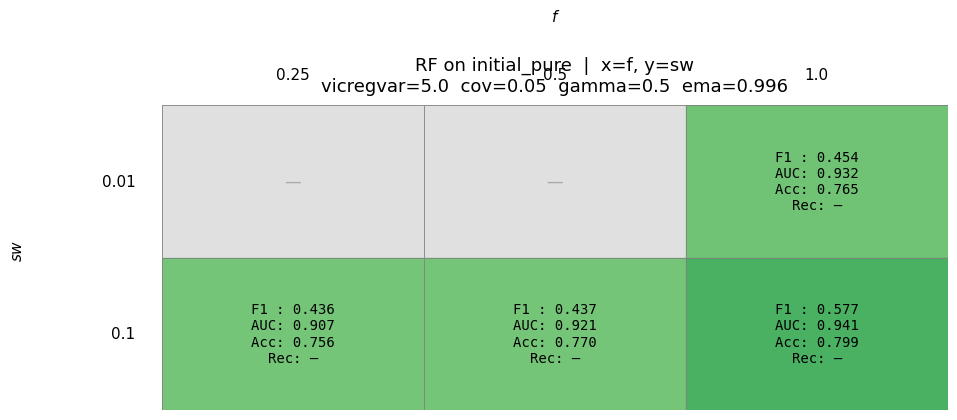

In [28]:
import re as _re

# ── Parseable hyperparameter patterns ─────────────────────────────────────────
_PARAM_RE = {
    "f":        r"_f([\d.]+)_",
    "sw":       r"_sw([\d.]+)_",
    "vicregvar": r"_vicregvar([\d.]+)_",
    "cov":      r"_cov([\d.]+)_",
    "gamma":    r"_gamma([\d.]+)_",
    "ema":      r"_ema([\d.]+)_",
}

def _parse_param(name, param):
    m = _re.search(_PARAM_RE[param], name + "_")
    return float(m.group(1)) if m else None

# ── Infer fixed params from the reference run ──────────────────────────────────
_ref_name  = Path(CONFIG["checkpoint"]).parent.name
_axis_x    = GRID_CONFIG["axis_x"]
_axis_y    = GRID_CONFIG["axis_y"]
_fixed = {
    p: _parse_param(_ref_name, p)
    for p in _PARAM_RE
    if p not in (_axis_x, _axis_y) and _parse_param(_ref_name, p) is not None
}
print("Fixed params:", _fixed)

# ── Scan run directories ────────────────────────────────────────────────────────
_root     = Path(GRID_CONFIG["outputs_root"])
_run_dirs = sorted(_root.glob(GRID_CONFIG["run_glob"]))
_run_dirs = [rd for rd in _run_dirs if _re.search(r"_f[\d.]+_sw[\d.]+", rd.name)]

_clf   = GRID_CONFIG["classifier"]
_ls    = GRID_CONFIG["label_set"]
_feat  = GRID_CONFIG["feature_type"]

_records = []
for rd in _run_dirs:
    params = {p: _parse_param(rd.name, p) for p in _PARAM_RE}
    # Filter: all fixed params must match (within float tolerance)
    if not all(
        params.get(k) is not None and abs(params[k] - v) < 1e-9
        for k, v in _fixed.items()
    ):
        continue
    json_path = rd / "data" / "classifiers" / f"{_clf}_{_ls}_{_feat}.json"
    if not json_path.exists():
        continue
    with open(json_path) as _fh:
        _d = json.load(_fh)
    _records.append({
        "x":   params[_axis_x],
        "y":   params[_axis_y],
        "f1":  _d.get("f1_macro",     float("nan")),
        "auc": _d.get("auc_macro",    float("nan")),
        "acc": _d.get("accuracy",     float("nan")),
        "rec": _d.get("recall_macro", float("nan")),
        "run": rd.name,
    })

print(f"Found {len(_records)} matching run(s)")

# ── Build axis value lists ─────────────────────────────────────────────────────
_xs = sorted(set(r["x"] for r in _records))
_ys = sorted(set(r["y"] for r in _records))

# Index records into a lookup dict
_grid = {(r["x"], r["y"]): r for r in _records}

# ── Render grid ────────────────────────────────────────────────────────────────
_ncols, _nrows = len(_xs), len(_ys)
_cw, _ch = 2.8, 1.8   # cell width/height in inches
fig, ax = plt.subplots(figsize=(_ncols * _cw + 1.2, _nrows * _ch + 0.8))
ax.set_xlim(0, _ncols); ax.set_ylim(0, _nrows); ax.invert_yaxis()
ax.axis("off")

for ri, yv in enumerate(_ys):
    for ci, xv in enumerate(_xs):
        rec = _grid.get((xv, yv))
        # Cell background: colour by F1 if available, grey if missing
        if rec and rec["f1"] == rec["f1"]:
            bg = plt.cm.YlGn(0.2 + 0.7 * rec["f1"])
        else:
            bg = (0.88, 0.88, 0.88, 1.0)
        ax.add_patch(plt.Rectangle([ci, ri], 1, 1, color=bg))
        ax.add_patch(plt.Rectangle([ci, ri], 1, 1, fill=False, edgecolor="grey", lw=0.6))
        if rec:
            def _v(val, label):
                return f"{label}: {val:.3f}" if val == val else f"{label}: —"
            txt = "\n".join([
                _v(rec["f1"],  "F1 "),
                _v(rec["auc"], "AUC"),
                _v(rec["acc"], "Acc"),
                _v(rec["rec"], "Rec"),
            ])
            ax.text(ci + 0.5, ri + 0.5, txt, ha="center", va="center",
                    fontsize=10, family="monospace",
                    color="black" if rec["f1"] < 0.7 else "black")
        else:
            ax.text(ci + 0.5, ri + 0.5, "—", ha="center", va="center",
                    fontsize=12, color="#aaaaaa")

# Axis labels
for ci, xv in enumerate(_xs):
    ax.text(ci + 0.5, -0.15, str(xv), ha="center", va="bottom", fontsize=11)
for ri, yv in enumerate(_ys):
    ax.text(-0.1, ri + 0.5, str(yv), ha="right", va="center", fontsize=11)

ax.set_title(
    f"{_clf.upper()} on {_ls}  |  x={_axis_x}, y={_axis_y}\n"
    + "  ".join(f"{k}={v}" for k, v in _fixed.items()),
    fontsize=13, pad=10
)
ax.text(_ncols / 2, -0.55, _axis_x, ha="center", fontsize=11, fontstyle="italic")
ax.text(-0.55, _nrows / 2, _axis_y, ha="center", fontsize=11, fontstyle="italic",
        rotation=90, transform=ax.transData)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sweep_grid_{_axis_x}_vs_{_axis_y}_{_clf}.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 8. Confusion Matrix (BYOL vs Supervised Baseline)

In [29]:
CM_CONFIG = {
    "label_set":       "initial_pure",   # must match key in projs_cache
    "byol_classifier": "random_forest",  # "random_forest" | "knn" | "linear_probe"
    "baseline_model":  "smoke",          # substring matched against baseline run dir names
    "baseline_dir":    "../outputs/supervised_baseline_classifiers",
    "n_estimators":    200,
    "n_neighbors":     15,
}

In [30]:
_ls  = CM_CONFIG["label_set"]
_key = f"lotss_{_ls}"
_cp  = projs_cache[_key]

X_tr = _cp["projs"][_cp["split_ids"] == 0]
y_tr = _cp["labels"][_cp["split_ids"] == 0]
X_te = _cp["projs"][_cp["split_ids"] == 2]
y_te_byol = _cp["labels"][_cp["split_ids"] == 2]

_byol_clf = CM_CONFIG["byol_classifier"]
if _byol_clf == "linear_probe":
    _clf_cm   = probe_results[_key]["clf"]
    _scaler   = probe_results[_key]["scaler"]
    X_te_s    = _scaler.transform(X_te)
    y_pred_byol = _clf_cm.predict(X_te_s)
else:
    _scaler_cm = StandardScaler()
    X_tr_s = _scaler_cm.fit_transform(X_tr)
    X_te_s = _scaler_cm.transform(X_te)
    if _byol_clf == "random_forest":
        _clf_cm = RandomForestClassifier(n_estimators=CM_CONFIG["n_estimators"],
                                         random_state=SEED, n_jobs=-1)
    elif _byol_clf == "knn":
        _clf_cm = KNeighborsClassifier(n_neighbors=CM_CONFIG["n_neighbors"],
                                       metric="euclidean", n_jobs=-1)
    _clf_cm.fit(X_tr_s, y_tr)
    y_pred_byol = _clf_cm.predict(X_te_s)

print(f"BYOL {_byol_clf}: N_test={len(y_te_byol)}")


BYOL random_forest: N_test=2005


In [31]:
_bdir = Path(CM_CONFIG["baseline_dir"])
_tag  = CM_CONFIG["baseline_model"]

_candidates = [d for d in _bdir.iterdir()
               if d.is_dir() and _tag in d.name.lower()
               and (d / "test_probs.npy").exists()]
if not _candidates:
    raise FileNotFoundError(f"No baseline run found for '{_tag}' in {_bdir}")
_brun = sorted(_candidates, key=lambda d: d.stat().st_mtime)[-1]

_probs_raw  = np.load(_brun / "test_probs.npy")   # (N, n_classes)
_labels_raw = np.load(_brun / "test_labels.npy")  # (N, n_classes) multi-hot

if _probs_raw.shape[1] != n_cls:
    raise ValueError(
        f"Baseline '{_brun.name}' has {_probs_raw.shape[1]} output classes "
        f"but confusion matrix expects {n_cls}. "
        f"Pick a baseline trained on the same label set."
    )

# Apply initial_pure filter: keep only sources with exactly one initial label
_pure_mask  = _labels_raw.sum(axis=1) == 1
_probs_base = _probs_raw[_pure_mask]
_labels_base = _labels_raw[_pure_mask]

y_pred_base = _probs_base.argmax(axis=1)
y_te_base   = _labels_base.argmax(axis=1)
print(f"Baseline {_tag}: {_brun.name}")
print(f"  N_test (all): {len(_probs_raw)}  →  N_test (pure): {len(_probs_base)}")

Baseline smoke: smoke_cls_cnn_20260511_1232
  N_test (all): 1519  →  N_test (pure): 1342


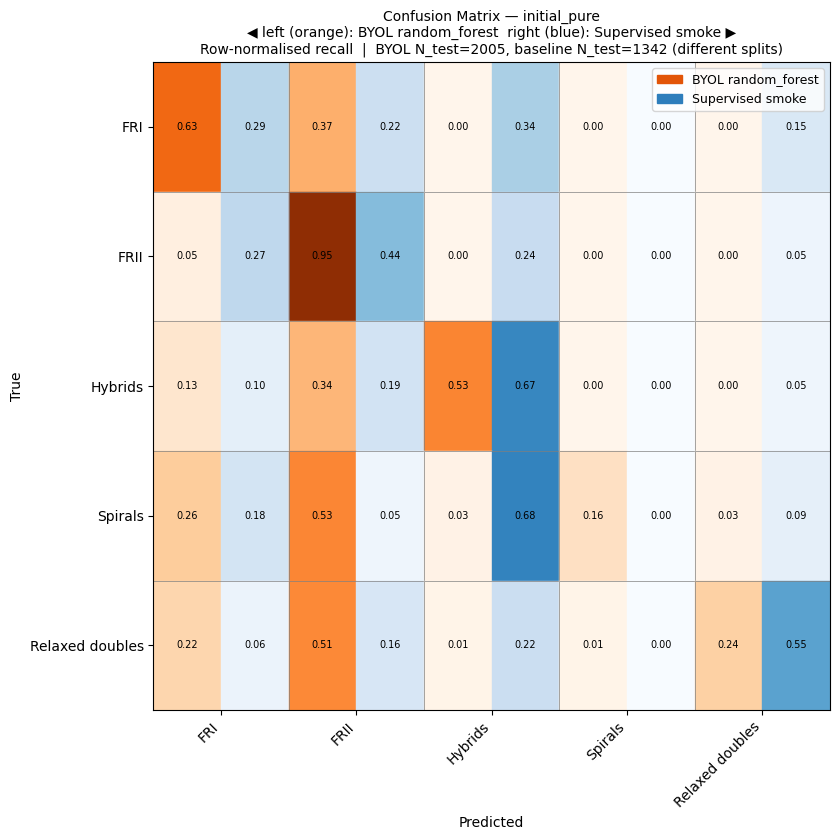

In [32]:
_class_names = [ALL_CLASS_NAMES[i] for i in LABEL_SETS[_ls]]
n_cls = len(_class_names)

cm_b = confusion_matrix(y_te_byol,  y_pred_byol, labels=list(range(n_cls)))
cm_s = confusion_matrix(y_te_base,  y_pred_base,  labels=list(range(n_cls)))

# Row-normalise (recall per class)
cm_b_n = cm_b / cm_b.sum(axis=1, keepdims=True).clip(min=1)
cm_s_n = cm_s / cm_s.sum(axis=1, keepdims=True).clip(min=1)

cmap_b = plt.cm.Oranges
cmap_s = plt.cm.Blues

fig, ax = plt.subplots(figsize=(n_cls * 1.5 + 1, n_cls * 1.5 + 1))
ax.set_xlim(0, n_cls); ax.set_ylim(0, n_cls)
ax.invert_yaxis()

for i in range(n_cls):
    for j in range(n_cls):
        # Left half — BYOL
        ax.add_patch(plt.Rectangle([j, i], 0.5, 1, color=cmap_b(cm_b_n[i, j])))
        # Right half — baseline
        ax.add_patch(plt.Rectangle([j+0.5, i], 0.5, 1, color=cmap_s(cm_s_n[i, j])))
        # Value labels
        ax.text(j+0.25, i+0.5, f"{cm_b_n[i,j]:.2f}", ha="center", va="center", fontsize=7)
        ax.text(j+0.75, i+0.5, f"{cm_s_n[i,j]:.2f}", ha="center", va="center", fontsize=7)
        # Cell border
        ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=False, edgecolor="grey", lw=0.5))

ax.set_xticks(np.arange(n_cls) + 0.5)
ax.set_xticklabels(_class_names, rotation=45, ha="right")
ax.set_yticks(np.arange(n_cls) + 0.5)
ax.set_yticklabels(_class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(
    f"Confusion Matrix — {_ls}\n"
    f"◀ left (orange): BYOL {CM_CONFIG['byol_classifier']}  "
    f"right (blue): Supervised {CM_CONFIG['baseline_model']} ▶\n"
    f"Row-normalised recall  |  BYOL N_test={len(y_te_byol)}, "
    f"baseline N_test={len(y_te_base)} (different splits)",
    fontsize=10
)
ax.legend(handles=[
    mpatches.Patch(color=plt.cm.Oranges(0.7), label=f"BYOL {CM_CONFIG['byol_classifier']}"),
    mpatches.Patch(color=plt.cm.Blues(0.7),   label=f"Supervised {CM_CONFIG['baseline_model']}"),
], loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix_{_ls}.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Label-Fraction Experiment

Train logistic regression probes on subsampled fractions of the train-split
projections. Tests how performance scales with the amount of labelled data,
evaluated on the fixed test split.

In [33]:
cp         = projs_cache["lotss_initial_pure"]
X_tr_all   = cp["projs"][cp["split_ids"] == 0]
y_tr_all   = cp["labels"][cp["split_ids"] == 0]
X_te       = cp["projs"][cp["split_ids"] == 2]
y_te       = cp["labels"][cp["split_ids"] == 2]

scaler_frac  = StandardScaler().fit(X_tr_all)
X_tr_all_s   = scaler_frac.transform(X_tr_all)
X_te_s       = scaler_frac.transform(X_te)

fractions    = [0.05, 0.10, 0.25, 0.50, 0.75, 1.0]
frac_results = {}
rng_fr       = np.random.default_rng(SEED)

for f in fractions:
    n   = max(4, int(f * len(X_tr_all_s)))   # >=2 per class for binary
    idx = rng_fr.choice(len(X_tr_all_s), size=n, replace=False)
    clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    clf.fit(X_tr_all_s[idx], y_tr_all[idx])
    y_pred = clf.predict(X_te_s)
    frac_results[f] = {
        "n_train":  n,
        "accuracy": accuracy_score(y_te, y_pred),
        "f1":       f1_score(y_te, y_pred, average="macro", zero_division=0),
    }
    print(f"  f={f:.2f}  n={n:4d}  "
          f"acc={frac_results[f]['accuracy']:.3f}  "
          f"F1={frac_results[f]['f1']:.3f}")

  f=0.05  n= 234  acc=0.776  F1=0.553
  f=0.10  n= 469  acc=0.777  F1=0.606
  f=0.25  n=1172  acc=0.791  F1=0.656
  f=0.50  n=2345  acc=0.800  F1=0.652
  f=0.75  n=3517  acc=0.806  F1=0.668
  f=1.00  n=4690  acc=0.806  F1=0.656


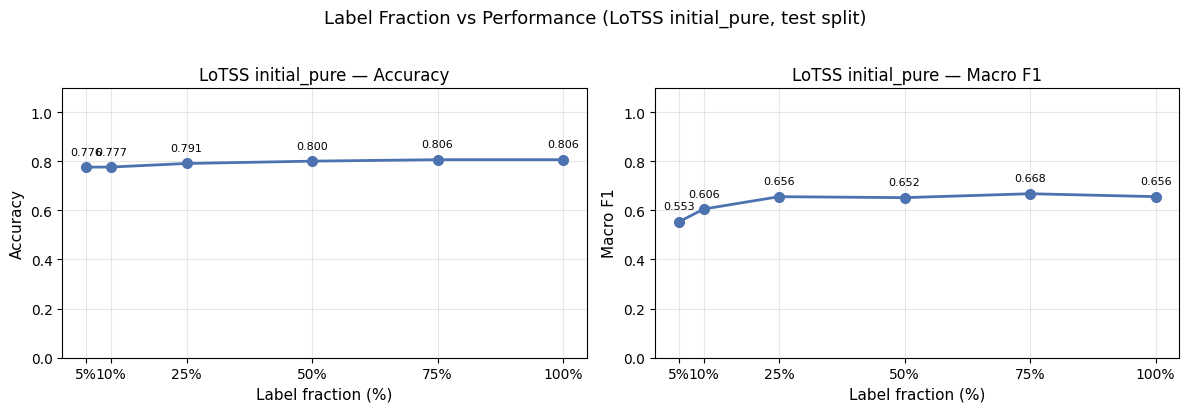

Saved → notebooks/outputs/label_fraction_lotss.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xs_pct = [f * 100 for f in fractions]

for ax, metric, ylabel in zip(axes, ["accuracy", "f1"], ["Accuracy", "Macro F1"]):
    ys = [frac_results[f][metric] for f in fractions]
    ax.plot(xs_pct, ys, "o-", color="#4C72B0", linewidth=2, markersize=7)
    for x_pt, y_pt in zip(xs_pct, ys):
        ax.annotate(f"{y_pt:.3f}", (x_pt, y_pt),
                    textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=8)
    ax.set_xlabel("Label fraction (%)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"LoTSS initial_pure — {ylabel}", fontsize=12)
    ax.set_xticks(xs_pct)
    ax.set_xticklabels([f"{x:.0f}%" for x in xs_pct])
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)

plt.suptitle("Label Fraction vs Performance (LoTSS initial_pure, test split)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/label_fraction_lotss.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR}/label_fraction_lotss.png")